# Qutritium Tutorial: Qutrit Bell state

This notebook demonstrates core features of Qutritium

1. Building qutrit circuits with Gate(s)
2. Simulating statevector simulator
3. Sampling measurement outcomes
4. SU(3) decomposition which mainly derived from Vitanov work. Please check references from transpilation.py
5. Plotting

In [6]:
import numpy as np

import qutritium

print(f"Qutritium version: {qutritium.__version__}")

Qutritium version: 1.2.0


## 1. Single-qutrit gates

A qutrit has three computational basis states: $|0\rangle$, $|1\rangle$, $|2\rangle$.

The qutrit Hadamard gate $H_3$ (the 3×3 discrete Fourier transform divided by $\sqrt{3}$)
creates an equal superposition from $|0\rangle$.

In [ ]:
from qutritium import QutritCircuit, StatevectorSimulator
from qutritium.gates import H3, X01, X12, Rx01, Rz01, CSUM
from qutritium.circuit.utils import print_statevector

# Apply H3 to a single qutrit
qc = QutritCircuit(n_qutrit=1, initial_state=None)
qc.append(H3(), first_qutrit=0)

sim = StatevectorSimulator(qc)
state = sim.return_final_state()

print("H3|0> =")
print_statevector(state, n_qutrit=1)
print(f"\nAmplitude magnitudes: {np.abs(state.flatten()).round(6)}")
print(f"Probabilities: {(np.abs(state.flatten()) ** 2).round(6)}")

Each amplitude has magnitude $1/\sqrt{3} \approx 0.5774$, giving equal probabilities of $1/3$ for each outcome.

## 2. Subspace Pauli gates

Qutrit Pauli-X gates operate on two-level subspaces:
- `X01`: swaps $|0\rangle \leftrightarrow |1\rangle$
- `X12`: swaps $|1\rangle \leftrightarrow |2\rangle$

In [9]:
# X01 flips |0> to |1>
qc_x01 = QutritCircuit(1, None)
qc_x01.append(X01(), first_qutrit=0)
state_x01 = StatevectorSimulator(qc_x01).return_final_state()
print("X01|0> =")
print_statevector(state_x01, 1)

# X12 on |1> gives |2>
qc_x12 = QutritCircuit(1, None)
qc_x12.append(X01(), first_qutrit=0)  # |0> -> |1>
qc_x12.append(X12(), first_qutrit=0)  # |1> -> |2>
state_x12 = StatevectorSimulator(qc_x12).return_final_state()
print("\nX12 . X01 |0> =")
print_statevector(state_x12, 1)

X01|0> =
State: 
(1+0j) |1>

X12 . X01 |0> =
State: 
(1+0j) |2>


## 3. Qutrit Bell State

The qutrit Bell state is:
$$|\Phi^+\rangle = \frac{1}{\sqrt{3}}\bigl(|00\rangle + |11\rangle + |22\rangle\bigr)$$

Preparation: apply $H_3$ on qutrit 0, then CSUM (controlled-sum modulo 3) on qutrits 0,1.

In [15]:
# Build the Bell state circuit
bell = QutritCircuit(n_qutrit=2, initial_state=None)
bell.append(H3(), first_qutrit=0)
bell.append(CSUM(), first_qutrit=0, second_qutrit=1)

# Inspect the statevector
sim_bell = StatevectorSimulator(bell)
bell_state = sim_bell.return_final_state()
print("Bell state:")
print_statevector(bell_state, n_qutrit=2)
# Visualize the circuit
print(bell.draw())

Bell state:
State: 
(0.5773502691896258+0j) |00> + 
(0.5773502691896258+0j) |11> + 
(0.5773502691896258+0j) |22>

q0: ─ H3 ── CSUM─● ──
q1: ─────── CSUM─○ ──


q0: ─ H3 ── CSUM─● ──
q1: ─────── CSUM─○ ──



## 4. Measurement sampling

In [12]:
# Add measurement and sample
bell_meas = QutritCircuit(n_qutrit=2, initial_state=None)
bell_meas.append(H3(), first_qutrit=0)
bell_meas.append(CSUM(), first_qutrit=0, second_qutrit=1)
bell_meas.measure_all()

sim_meas = StatevectorSimulator(bell_meas)
sim_meas.run(num_shots=6000)
counts = sim_meas.get_counts()
print(f"Measurement counts (6000 shots): {counts}")
print(f"\nOutcomes: {sorted(counts.keys())}")
print("Only |00>, |11>, |22> appear — perfect correlations.")

Measurement counts (6000 shots): {'11': 2030, '22': 1963, '00': 2007}

Outcomes: ['00', '11', '22']
Only |00>, |11>, |22> appear — perfect correlations.


## 5. Plotting measurement results

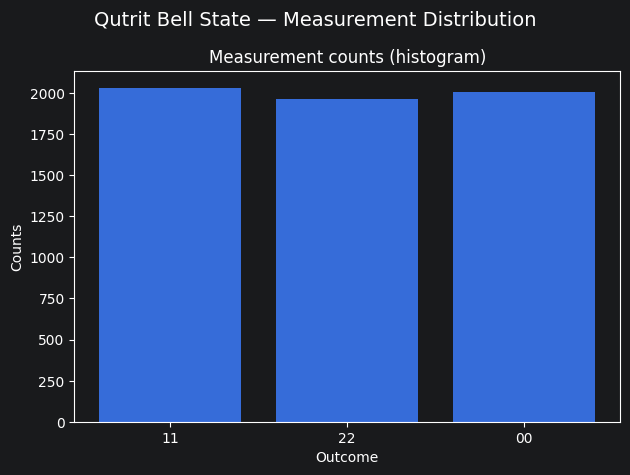

In [13]:
import matplotlib.pyplot as plt

fig = sim_meas.plot(plot_type="histogram")
fig.suptitle("Qutrit Bell State — Measurement Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Density matrix and entanglement verification

In [14]:
# Get the density matrix
sim_rho = StatevectorSimulator(bell)
rho = sim_rho.density_matrix()

print(f"Density matrix shape: {rho.shape}")
print(f"Trace: {np.trace(rho).real:.6f}")
print(f"Hermitian: {np.allclose(rho, rho.conj().T)}")

# Partial trace over qutrit B to get reduced density matrix of A
rho_A = np.zeros((3, 3), dtype=complex)
for b in range(3):
    proj_b = np.zeros((3, 1), dtype=complex)
    proj_b[b, 0] = 1.0
    bra_b = np.kron(np.eye(3), proj_b.T)
    ket_b = np.kron(np.eye(3), proj_b)
    rho_A += bra_b @ rho @ ket_b

print(f"\nReduced density matrix of qutrit A:")
print(np.round(rho_A.real, 4))
print(f"\nThis is I/3 (maximally mixed) — confirming maximal entanglement.")

Density matrix shape: (9, 9)
Trace: 1.000000
Hermitian: True

Reduced density matrix of qutrit A:
[[0.3333 0.     0.    ]
 [0.     0.3333 0.    ]
 [0.     0.     0.3333]]

This is I/3 (maximally mixed) — confirming maximal entanglement.


## 7. Parametric rotation gates

In [16]:
# Rx01(pi) rotates |0> to -i|1> (up to global phase)
qc_rx = QutritCircuit(1, None)
qc_rx.append(Rx01(np.pi), first_qutrit=0)
state_rx = StatevectorSimulator(qc_rx).return_final_state()
print("Rx01(π)|0> =")
print_statevector(state_rx, 1)

# Rz01 applies a phase
qc_rz = QutritCircuit(1, None)
qc_rz.append(Rz01(np.pi / 2), first_qutrit=0)
state_rz = StatevectorSimulator(qc_rz).return_final_state()
print("\nRz01(π/2)|0> =")
print_statevector(state_rz, 1)
print(f"  Phase: {np.angle(state_rz[0, 0]):.4f} rad (expected {-np.pi / 4:.4f})")

Rx01(π)|0> =
State: 
(6.123233995736766e-17+0j) |0> + 
-1j |1>

Rz01(π/2)|0> =
State: 
(0.7071067811865476-0.7071067811865476j) |0>
  Phase: -0.7854 rad (expected -0.7854)


## 8. SU(3) Decomposition

Any 3×3 unitary can be decomposed into the canonical form:
$$U = U_d(\phi_6, \phi_5, \phi_4) \cdot r_{01}(\phi_3, \theta_3) \cdot r_{12}(\phi_2, \theta_2) \cdot r_{01}(\phi_1, \theta_1)$$

In [17]:
from qutritium import SU3Decomposition

# Decompose the Hadamard
h3_matrix = H3().matrix()
dec_h3 = SU3Decomposition(h3_matrix, qutrit_index=0, n_qutrits=1)
fidelity_h3 = np.abs(np.trace(h3_matrix.conj().T @ dec_h3.reconstruct())) / 3
print(f"H3 decomposition fidelity: {fidelity_h3:.10f}")
print(f"H3 decomposition angles: {dec_h3.angles}")

H3 decomposition fidelity: 1.0000000000
H3 decomposition angles: DecompositionAngles(theta1=1.5707957078968966, theta2=1.9106338956261688, theta3=1.5707957078968966, phi1=-2.6179938779914935, phi2=-2.617993877991495, phi3=-1.047197639327731, phi4=2.0943951023931953, phi5=-3.141592653589794, phi6=-6.806784170909019)


In [18]:
from qutritium import SU3Decomposition

# Decompose the Hadamard
h3_matrix = H3().matrix()
dec_h3 = SU3Decomposition(h3_matrix, qutrit_index=0, n_qutrits=1)
fidelity_h3 = np.abs(np.trace(h3_matrix.conj().T @ dec_h3.reconstruct())) / 3
print(f"H3 decomposition fidelity: {fidelity_h3:.10f}")
print(f"H3 decomposition angles: {dec_h3.angles}")

H3 decomposition fidelity: 1.0000000000
H3 decomposition angles: DecompositionAngles(theta1=1.5707957078968966, theta2=1.9106338956261688, theta3=1.5707957078968966, phi1=-2.6179938779914935, phi2=-2.617993877991495, phi3=-1.047197639327731, phi4=2.0943951023931953, phi5=-3.141592653589794, phi6=-6.806784170909019)


In [19]:
# Convert decomposition to a circuit and verify
dec_circuit = dec_h3.to_circuit()
print(f"Decomposition circuit: {dec_circuit}")

# Run through simulator and compare final states
qc_direct = QutritCircuit(1, None)
qc_direct.append(H3(), first_qutrit=0)
state_direct = StatevectorSimulator(qc_direct).return_final_state()

state_decomp = StatevectorSimulator(dec_circuit).return_final_state()

# Compare (up to global phase)
overlap = np.abs(state_direct.conj().T @ state_decomp)[0, 0]
print(f"State overlap |<direct|decomp>|: {overlap:.10f}")

Decomposition circuit: QutritCircuit(n_qutrit=1, ops=4)
State overlap |<direct|decomp>|: 1.0000000000


## 9. Gate library overview

In [20]:
from qutritium.gates import (
    I3, X01, X02, X12, Y01, Y02, Y12, Z01, Z02, Z12,
    XPlus, XMinus, H3, S3, T3, UFT,
    Rx01, Ry02, Rz12,
    G01, Ud,
    CSUM, CSUMDag, CNOT3, CPhase, SWAP3,
)

fixed_1q = [I3(), X01(), X02(), X12(), Y01(), Y02(), Y12(),
            Z01(), Z02(), Z12(), XPlus(), XMinus(), H3(), S3(), T3(), UFT()]
param_1q = [Rx01(0.5), Ry02(1.0), Rz12(0.3), G01(0.5, 0.3), Ud(0.1, 0.2, 0.3)]
gates_2q = [CSUM(), CSUMDag(), CNOT3(), CPhase(), SWAP3()]

print(f"Fixed single-qutrit gates: {len(fixed_1q)}")
print(f"  {', '.join(g.label for g in fixed_1q)}")
print(f"\nParametric families: Rx/Ry/Rz (9 subspace variants), G (3 variants), Ud")
print(f"  Total parametric gate classes: 13")
print(f"\nTwo-qutrit gates: {len(gates_2q)}")
print(f"  {', '.join(g.label for g in gates_2q)}")

# Verify all are unitary
all_gates = fixed_1q + param_1q + gates_2q
all_unitary = all(g.is_unitary() for g in all_gates)
print(f"\nAll {len(all_gates)} gates unitary: {all_unitary}")

Fixed single-qutrit gates: 16
  I3, X01, X02, X12, Y01, Y02, Y12, Z01, Z02, Z12, X+, X-, H3, S3, T3, UFT

Parametric families: Rx/Ry/Rz (9 subspace variants), G (3 variants), Ud
  Total parametric gate classes: 13

Two-qutrit gates: 5
  CSUM, CSUM†, CNOT3, CPhase, SWAP3

All 26 gates unitary: True
